In [1]:
#!/usr/bin/env python
# coding: utf-8

# # Diamond Predictions using Various Models

# Three models will be evaluated which is Standard Linear Regression, Random Forest Reggressor and K means Regressor.

# In[1]:


import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import  LinearRegression, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import mean_squared_error
import seaborn as sns
import matplotlib.pyplot as plt


In [9]:
#load in the data
df = pd.read_csv('C:\\Users\\3019\\machinelearning\\Transport Analytics_DS for Python1.csv')


In [10]:
df.head()


,PURCHNAME,DELIVERY_LOCATION,LINEAMOUNT,PALLETS
0,Hoddesdon Distribution Ltd,Mr Shabir Ahmed36 Park Road Oldham\nOldham\nOL...,275.00,5.00
1,Lenham Storage Co. Ltd,Waitrose National Dist Ctre Atkinson Way\nMilt...,162.63,14.00
2,Lenham Storage Co. Ltd,Waitrose National Dist Ctre Atkinson Way\nMilt...,189.74,12.00
3,Roche freight (Ireland) Ltd,Killamonan Road The Ward Co.Dublin\nCo dublin\...,305.24,1.83
4,Lenham Storage Co. Ltd,Unit 2D Central Boulevard Prologis Park Cov...,135.10,31.00


In [11]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1386 entries, 0 to 1385
Data columns (total 4 columns):
PURCHNAME            1386 non-null object
DELIVERY_LOCATION    1386 non-null object
LINEAMOUNT           1386 non-null float64
PALLETS              1386 non-null float64
dtypes: float64(2), object(2)
memory usage: 43.4+ KB


In [12]:
df.describe()


,LINEAMOUNT,PALLETS
count,1386.000000,1386.000000
mean,280.795498,9.837078
std,359.061598,8.232600
min,9.000000,0.460000
25%,135.000000,3.000000
50%,240.000000,6.000000
75%,379.000000,16.000000
max,11448.000000,48.000000


In [13]:
df.columns


Index(['PURCHNAME', 'DELIVERY_LOCATION', 'LINEAMOUNT', 'PALLETS '], dtype='object')

In [14]:
df.dtypes


PURCHNAME             object
DELIVERY_LOCATION     object
LINEAMOUNT           float64
PALLETS              float64
dtype: object

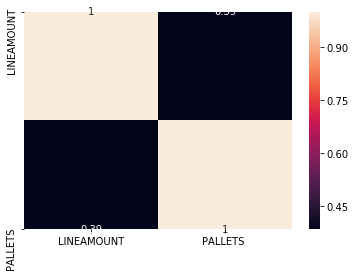

In [15]:
sns.heatmap(df.corr(),annot=True);


In [16]:
df_trans=pd.get_dummies(df)
X = df_trans.drop(['LINEAMOUNT'],axis=1)
y=df_trans['LINEAMOUNT']
features = X.columns


In [17]:

plt.figure(figsize=(20,10))
sns.heatmap(df_trans.corr(),annot=True);


C:\Users\3019\AppData\Local\Continuum\anaconda3\lib\site-packages\matplotlib\backends\backend_agg.py:211: RuntimeWarning: Glyph 9 missing from current font.
  font.set_text(s, 0.0, flags=flags)
C:\Users\3019\AppData\Local\Continuum\anaconda3\lib\site-packages\matplotlib\backends\backend_agg.py:180: RuntimeWarning: Glyph 9 missing from current font.
  font.set_text(s, 0, flags=flags)


Error in callback <function flush_figures at 0x000002DE31F4BE58> (for post_execute):


KeyboardInterrupt: 

In [19]:
s = StandardScaler()
X = s.fit_transform(X)



In [20]:
X_train,X_test,y_train,y_test = train_test_split(X,y)


In [21]:
models_eval = pd.DataFrame(index=['Null','KNN','MLR'],columns=['RMSE'])


In [22]:
ypred_null = y_train.mean()


In [23]:
knn = KNeighborsRegressor(n_neighbors=7)
knn.fit(X_train,y_train)


# In[21]:


y_pred = knn.predict(X_test)


# # Random Forrest Regression

# In[22]:


rf = RandomForestRegressor(n_estimators=10)
rf.fit(X_train,y_train)
y_pred2=y_pred = rf.predict(X_test)


# # Linear Regression

# In[23]:


lin = LinearRegression()
lin = lin.fit(X_train,y_train)
y_pred3 = lin.predict(X_test)


# # Lasso Regression

# In[24]:


lasso = Lasso()
lasso.fit(X_train,y_train)
y_pred4 = lasso.predict(X_test)



In [24]:
model_eval=pd.DataFrame(index=['KNN','MLR'],columns=['RMSE'])
model_eval.loc['KNN','RMSE']=np.sqrt(mean_squared_error(y_test,y_pred))
model_eval.loc['RF','RMSE'] = np.sqrt(mean_squared_error(y_test,y_pred2))
model_eval.loc['MLR','RMSE'] = np.sqrt(mean_squared_error(y_test,y_pred3))
model_eval.loc['Lasso','RMSE'] = np.sqrt(mean_squared_error(y_test,y_pred4))
model_eval.loc['NULL','RMSE'] = ypred_null
model_eval



,RMSE
KNN,73.4631
MLR,5.04357e+16
RF,73.4631
Lasso,89.1668
NULL,276.687


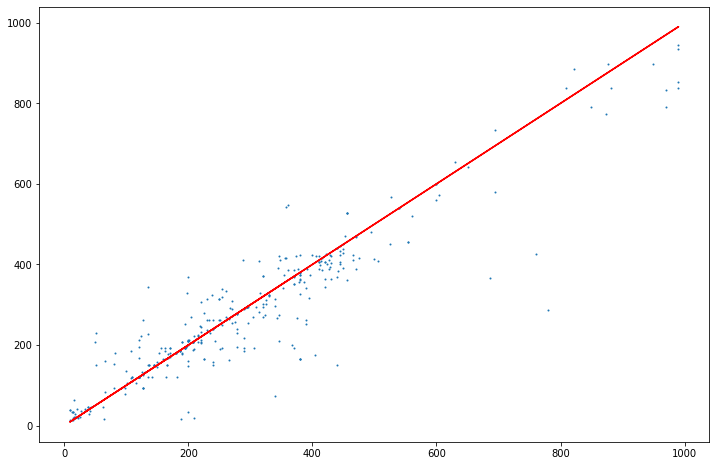

In [25]:
fig, ax = plt.subplots(figsize=(12,8))
ax.scatter(y_test,y_pred,s=1)
ax.plot(y_test,y_test,color='red')



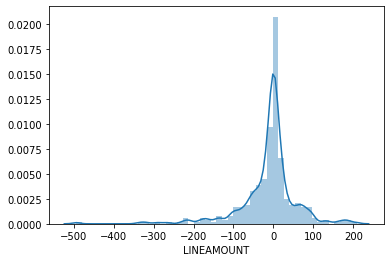

In [26]:
sns.distplot(y_pred-y_test)


In [27]:
lin=LinearRegression()
lin.fit(X_train,y_train)
y_pred2 = lin.predict(X_test)
model_eval.loc['MLR','RMSE']=np.sqrt(mean_squared_error(y_pred2,y_test))


In [28]:
from sklearn.ensemble import ExtraTreesRegressor
model =ExtraTreesRegressor()
model.fit(X,y)


C:\Users\3019\AppData\Local\Continuum\anaconda3\lib\site-packages\sklearn\ensemble\forest.py:245: FutureWarning: The default value of n_estimators will change from 10 in version 0.20 to 100 in 0.22.
  "10 in version 0.20 to 100 in 0.22.", FutureWarning)


ExtraTreesRegressor(bootstrap=False, criterion='mse', max_depth=None,
                    max_features='auto', max_leaf_nodes=None,
                    min_impurity_decrease=0.0, min_impurity_split=None,
                    min_samples_leaf=1, min_samples_split=2,
                    min_weight_fraction_leaf=0.0, n_estimators=10, n_jobs=None,
                    oob_score=False, random_state=None, verbose=0,
                    warm_start=False)

In [29]:
model.feature_importances_.tolist()


[0.1185612126752557,
 0.00012654660024706153,
 0.012887195444097648,
 0.0007645426132406477,
 0.0018804868640201924,
 0.002089458072159981,
 0.00045019363419449796,
 0.0009440876644632216,
 0.0004966847357833023,
 2.9315544983817795e-05,
 9.66874004734919e-05,
 0.0009362193123335431,
 0.7035836013570207,
 0.0001515211675522925,
 0.0015151303745786664,
 3.405199548039131e-05,
 3.6951391203571506e-06,
 0.00020969272838435848,
 6.988762621244888e-06,
 0.0003116612970150014,
 0.0,
 0.0,
 3.161086273184381e-05,
 0.0,
 9.416853730960746e-05,
 7.718494920850085e-07,
 3.5589831310557645e-05,
 0.0,
 1.5872051964337523e-05,
 0.002879847928851552,
 0.00031327914906075324,
 6.508291700927158e-06,
 0.0,
 0.0,
 2.350039916496598e-06,
 5.3170250021121476e-05,
 6.402017293206902e-07,
 0.0,
 1.095484590527307e-06,
 0.00016530588934326535,
 2.030343645949088e-07,
 0.001045218323548219,
 1.8819539805164854e-07,
 1.4280076163184699e-05,
 7.48287099490535e-06,
 0.002311367297675867,
 0.0005265054351391755,

In [30]:
df['prediction']=knn.predict(X)


In [31]:
df.head()


,PURCHNAME,DELIVERY_LOCATION,LINEAMOUNT,PALLETS,prediction
0,Hoddesdon Distribution Ltd,Mr Shabir Ahmed36 Park Road Oldham\nOldham\nOL...,275.00,5.00,104.450000
1,Lenham Storage Co. Ltd,Waitrose National Dist Ctre Atkinson Way\nMilt...,162.63,14.00,141.127143
2,Lenham Storage Co. Ltd,Waitrose National Dist Ctre Atkinson Way\nMilt...,189.74,12.00,141.127143
3,Roche freight (Ireland) Ltd,Killamonan Road The Ward Co.Dublin\nCo dublin\...,305.24,1.83,347.945714
4,Lenham Storage Co. Ltd,Unit 2D Central Boulevard Prologis Park Cov...,135.10,31.00,260.138571


In [32]:
df_trans.describe()


,LINEAMOUNT,PALLETS,PURCHNAME_Barron Wood Distribution Ltd,PURCHNAME_DHL Express Ltd,PURCHNAME_DHL Global Forwarding UK Ltd,PURCHNAME_Fercam Austria Gmbh,PURCHNAME_Hoddesdon Distribution Ltd,PURCHNAME_Lenham Storage Co Ltd,PURCHNAME_Lenham Storage Co. Ltd,PURCHNAME_Roche freight (Ireland) Ltd,...,DELIVERY_LOCATION_Wakefield 41 Ind Est\nWakefield\nWF2 0XF\nGBR,DELIVERY_LOCATION_Waldrist Way\nErith\nDA18 4AG\nGBR,DELIVERY_LOCATION_Waterton Industrial Estate Cowbridge Road \nBridgend\nCF31 3PH\nGBR,DELIVERY_LOCATION_Welcome HouseGlover Street\nDigbeth\nB9 4EP\nGBR,DELIVERY_LOCATION_Wembley Stadium Industrial Estate First Way\nWembley\nHA9 0TU\nGBR,DELIVERY_LOCATION_WimbergerGasse-5\nAT-1070Vienna\nAUT,DELIVERY_LOCATION_Wincanton Elton Head oad\nSt Helens\nWA9 5AX\nGBR,DELIVERY_LOCATION_Windmill Lane\nSouthall\nUB2 4NA\nGBR,DELIVERY_LOCATION_c/o DHL Foxhills Ind Est\nScunthorpe\nDN159YA\nGBR,"DELIVERY_LOCATION_unit 5, Trafalgar Trading Estate\n82 Jeffreys Road\nLondon\nLondon\nEN3 7TY\nGBR"
count,1386.000000,1386.000000,1386.000000,1386.000000,1386.000000,1386.000000,1386.000000,1386.000000,1386.000000,1386.000000,...,1386.000000,1386.000000,1386.000000,1386.000000,1386.000000,1386.000000,1386.000000,1386.000000,1386.000000,1386.000000
mean,280.795498,9.837078,0.004329,0.004329,0.000722,0.003608,0.761905,0.093074,0.024531,0.002886,...,0.028139,0.001443,0.001443,0.000722,0.001443,0.000722,0.010101,0.009380,0.010823,0.000722
std,359.061598,8.232600,0.065676,0.065676,0.026861,0.059976,0.426071,0.290640,0.154747,0.053663,...,0.165428,0.037973,0.037973,0.026861,0.037973,0.026861,0.100031,0.096427,0.103504,0.026861
min,9.000000,0.460000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,135.000000,3.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,240.000000,6.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,379.000000,16.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,11448.000000,48.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [33]:
df_trans.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1386 entries, 0 to 1385
Columns: 220 entries, LINEAMOUNT to DELIVERY_LOCATION_unit 5, Trafalgar Trading Estate
82 Jeffreys Road
London
London
EN3 7TY
GBR
dtypes: float64(2), uint8(218)
memory usage: 316.8 KB


In [34]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1386 entries, 0 to 1385
Data columns (total 5 columns):
PURCHNAME            1386 non-null object
DELIVERY_LOCATION    1386 non-null object
LINEAMOUNT           1386 non-null float64
PALLETS              1386 non-null float64
prediction           1386 non-null float64
dtypes: float64(3), object(2)
memory usage: 54.3+ KB
